# 02 — Simulated Annealing: casas y hospitales

**Curso:** Inteligencia Artificial — Optimización

En este ejercicio usaremos el mismo problema de ubicación de hospitales del notebook de Hill Climbing. Así podremos comparar ambos algoritmos sobre el mismo espacio de estados, función de costo y vecindario.

![HillClimbing](https://drive.google.com/uc?export=view&id=13a1dTy2bf9BsgeSZH-cXqJndS1ZKU4DP)



## Objetivos

- implementar Simulated Annealing para un problema discreto;
- comprender la aceptación probabilística de soluciones peores;
- analizar el efecto de la temperatura y el enfriamiento;
- comparar Hill Climbing y Simulated Annealing sobre el mismo problema.

## 1. Problema de ubicación de hospitales

Tenemos una cuadrícula con varias casas y queremos ubicar $k$ hospitales.

El costo de una solución es la suma de la distancia de cada casa al hospital más cercano:

$$
J(H)=\sum_{c\in C}\min_{h\in H} d(c,h)
$$

Usaremos distancia Manhattan:

$$
d((r_1,c_1),(r_2,c_2))=|r_1-r_2|+|c_1-c_2|
$$

El objetivo es **minimizar** $J(H)$.

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 8
random.seed(SEED)
np.random.seed(SEED)

In [2]:
def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def total_cost(houses, hospitals):
    return sum(
        min(manhattan(house, hospital) for hospital in hospitals)
        for house in houses
    )


def plot_state(height, width, houses, hospitals, title=None):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_xticks(range(width))
    ax.set_yticks(range(height))
    ax.grid(True)

    if houses:
        rows, cols = zip(*houses)
        ax.scatter(cols, rows, marker="s", s=110, label="Casas")

    if hospitals:
        rows, cols = zip(*hospitals)
        ax.scatter(cols, rows, marker="P", s=180, label="Hospitales")

    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    ax.set_title(title or f"Costo = {total_cost(houses, hospitals)}")
    plt.tight_layout()
    plt.show()

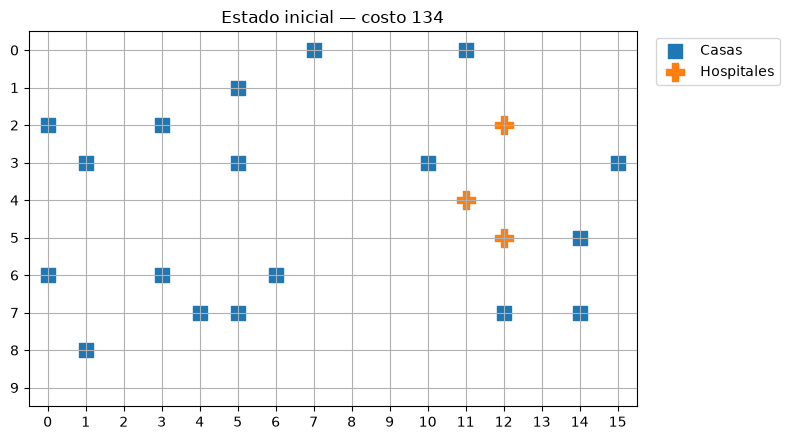

In [3]:
HEIGHT, WIDTH = 10, 16
NUM_HOUSES = 18
NUM_HOSPITALS = 3

all_cells = [
    (row, col)
    for row in range(HEIGHT)
    for col in range(WIDTH)
]

houses = set(random.sample(all_cells, NUM_HOUSES))
available = list(set(all_cells) - houses)
initial_hospitals = set(
    random.sample(available, NUM_HOSPITALS)
)

plot_state(
    HEIGHT,
    WIDTH,
    houses,
    initial_hospitals,
    title=(
        "Estado inicial — costo "
        f"{total_cost(houses, initial_hospitals)}"
    ),
)

## 2. Vecindario

Un estado está formado por las posiciones de los hospitales.

Un vecino se obtiene moviendo **un hospital** una celda hacia arriba, abajo, izquierda o derecha, siempre que la nueva posición:

- esté dentro de la cuadrícula;
- no contenga una casa;
- no esté ocupada por otro hospital.

In [4]:
def neighbors_of_state(height, width, houses, hospitals):
    neighbors = []
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for hospital in hospitals:
        for dr, dc in moves:
            candidate = (
                hospital[0] + dr,
                hospital[1] + dc,
            )

            if not (
                0 <= candidate[0] < height
                and 0 <= candidate[1] < width
            ):
                continue

            if candidate in houses or candidate in hospitals:
                continue

            new_state = set(hospitals)
            new_state.remove(hospital)
            new_state.add(candidate)
            neighbors.append(new_state)

    return neighbors


neighbors = neighbors_of_state(
    HEIGHT,
    WIDTH,
    houses,
    initial_hospitals,
)

print("Número de vecinos:", len(neighbors))
print("Costo actual:", total_cost(houses, initial_hospitals))
print(
    "Mejor costo vecino:",
    min(total_cost(houses, state) for state in neighbors),
)

Número de vecinos: 12
Costo actual: 134
Mejor costo vecino: 125


## 3. Hill Climbing como línea base

Hill Climbing siempre se mueve al mejor vecino disponible.

Si ningún vecino mejora el costo actual, se detiene.

Costo inicial: 134
Costo final: 62
Iteraciones: 13


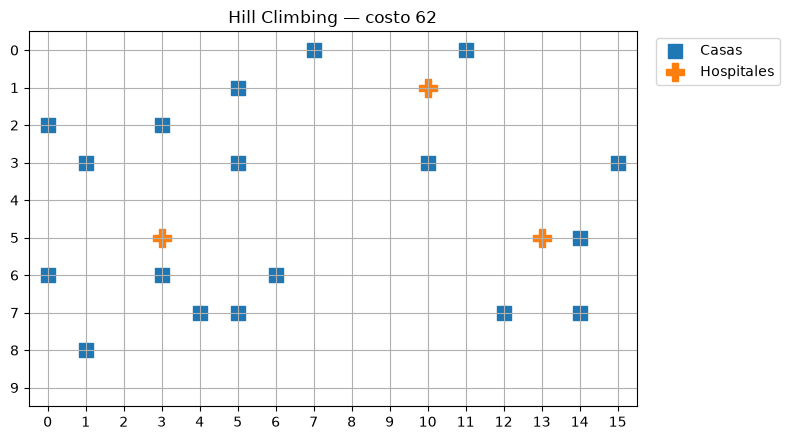

In [5]:
def hill_climbing(
    height,
    width,
    houses,
    initial_state,
    max_iterations=200,
    rng=None,
):
    rng = rng or random.Random()
    current = set(initial_state)
    current_cost = total_cost(houses, current)

    history = [current_cost]
    states = [set(current)]

    for _ in range(max_iterations):
        neighbors = neighbors_of_state(
            height,
            width,
            houses,
            current,
        )

        if not neighbors:
            break

        costs = [
            total_cost(houses, neighbor)
            for neighbor in neighbors
        ]
        best_cost = min(costs)

        if best_cost >= current_cost:
            break

        best_neighbors = [
            neighbor
            for neighbor, cost in zip(neighbors, costs)
            if cost == best_cost
        ]

        current = set(rng.choice(best_neighbors))
        current_cost = best_cost
        history.append(current_cost)
        states.append(set(current))

    return current, history, states


hc_solution, hc_history, hc_states = hill_climbing(
    HEIGHT,
    WIDTH,
    houses,
    initial_hospitals,
    rng=random.Random(SEED),
)

print("Costo inicial:", hc_history[0])
print("Costo final:", hc_history[-1])
print("Iteraciones:", len(hc_history) - 1)

plot_state(
    HEIGHT,
    WIDTH,
    houses,
    hc_solution,
    title=f"Hill Climbing — costo {hc_history[-1]}",
)

## 4. Regla de aceptación de Simulated Annealing

Sea:

$$
\Delta = J(H') - J(H)
$$

Como estamos minimizando:

- si $\Delta \leq 0$, el nuevo estado es igual o mejor y se acepta;
- si $\Delta > 0$, el nuevo estado es peor, pero puede aceptarse con probabilidad:

$$
P(\text{aceptar})=e^{-\Delta/T}
$$

Cuando $T$ es alta, el algoritmo explora. Cuando $T$ disminuye, se vuelve más conservador.

In [6]:
def acceptance_probability(delta_cost, temperature):
    if delta_cost <= 0:
        return 1.0

    if temperature <= 0:
        return 0.0

    return math.exp(-delta_cost / temperature)


for temperature in [0.1, 1, 5, 20]:
    probability = acceptance_probability(
        delta_cost=3,
        temperature=temperature,
    )
    print(
        f"T={temperature:>4}: "
        f"P(aceptar un aumento de 3)={probability:.3f}"
    )

T= 0.1: P(aceptar un aumento de 3)=0.000
T=   1: P(aceptar un aumento de 3)=0.050
T=   5: P(aceptar un aumento de 3)=0.549
T=  20: P(aceptar un aumento de 3)=0.861


## 5. Implementación

En cada iteración:

1. generamos los vecinos;
2. seleccionamos **uno al azar**;
3. calculamos $\Delta$;
4. aplicamos la regla de aceptación;
5. reducimos la temperatura.

Costo inicial: 134
Mejor costo: 56
Iteraciones: 1500


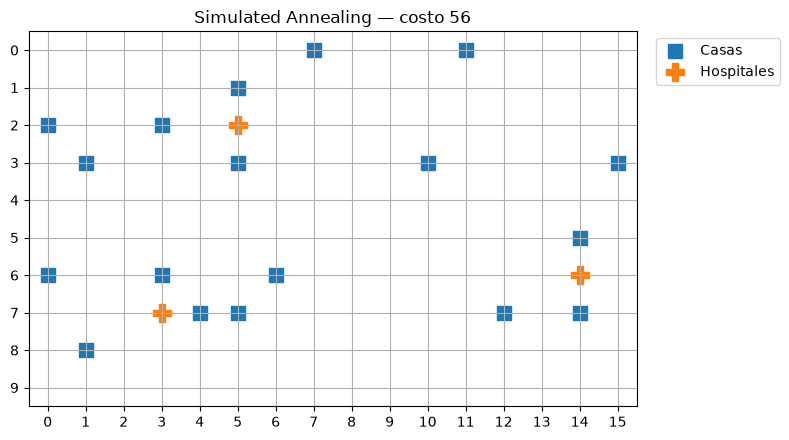

In [7]:
def simulated_annealing(
    height,
    width,
    houses,
    initial_state,
    iterations=1000,
    initial_temperature=20.0,
    cooling_rate=0.995,
    minimum_temperature=1e-3,
    rng=None,
):
    rng = rng or random.Random()

    current = set(initial_state)
    current_cost = total_cost(houses, current)

    best = set(current)
    best_cost = current_cost

    temperature = initial_temperature
    records = []

    for iteration in range(iterations):
        neighbors = neighbors_of_state(
            height,
            width,
            houses,
            current,
        )

        if not neighbors or temperature < minimum_temperature:
            break

        candidate = set(rng.choice(neighbors))
        candidate_cost = total_cost(houses, candidate)
        delta_cost = candidate_cost - current_cost

        probability = acceptance_probability(
            delta_cost,
            temperature,
        )
        accepted = rng.random() < probability

        if accepted:
            current = candidate
            current_cost = candidate_cost

            if current_cost < best_cost:
                best = set(current)
                best_cost = current_cost

        records.append({
            "iteration": iteration,
            "temperature": temperature,
            "current_cost": current_cost,
            "best_cost": best_cost,
            "delta_cost": delta_cost,
            "accepted": accepted,
        })

        temperature *= cooling_rate

    return best, records


sa_solution, sa_records = simulated_annealing(
    HEIGHT,
    WIDTH,
    houses,
    initial_hospitals,
    iterations=1500,
    initial_temperature=20,
    cooling_rate=0.995,
    rng=random.Random(SEED),
)

print("Costo inicial:", total_cost(houses, initial_hospitals))
print("Mejor costo:", total_cost(houses, sa_solution))
print("Iteraciones:", len(sa_records))

plot_state(
    HEIGHT,
    WIDTH,
    houses,
    sa_solution,
    title=(
        "Simulated Annealing — costo "
        f"{total_cost(houses, sa_solution)}"
    ),
)

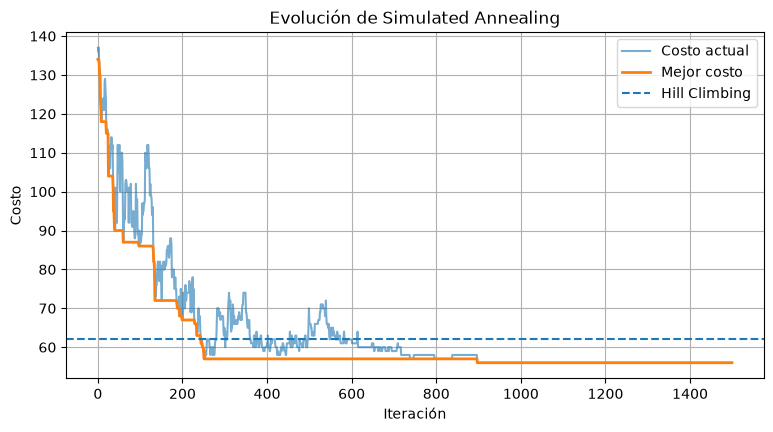

In [8]:
iterations = [record["iteration"] for record in sa_records]
current_costs = [record["current_cost"] for record in sa_records]
best_costs = [record["best_cost"] for record in sa_records]

plt.figure(figsize=(9, 4.5))
plt.plot(iterations, current_costs, alpha=0.6, label="Costo actual")
plt.plot(iterations, best_costs, linewidth=2, label="Mejor costo")
plt.axhline(
    hc_history[-1],
    linestyle="--",
    label="Hill Climbing",
)
plt.xlabel("Iteración")
plt.ylabel("Costo")
plt.title("Evolución de Simulated Annealing")
plt.legend()
plt.grid(True)
plt.show()

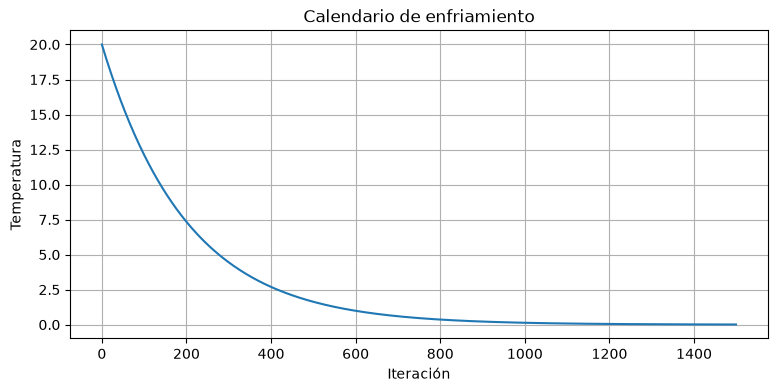

Porcentaje de movimientos aceptados: 36.2%


In [9]:
temperatures = [record["temperature"] for record in sa_records]
accepted = [record["accepted"] for record in sa_records]

plt.figure(figsize=(9, 4))
plt.plot(iterations, temperatures)
plt.xlabel("Iteración")
plt.ylabel("Temperatura")
plt.title("Calendario de enfriamiento")
plt.grid(True)
plt.show()

print(
    "Porcentaje de movimientos aceptados:",
    f"{100 * np.mean(accepted):.1f}%",
)

## 6. Comparación estadística

Una sola corrida puede ser engañosa. Ejecutaremos ambos algoritmos desde diferentes estados iniciales.

In [10]:
def random_initial_state(
    height,
    width,
    houses,
    num_hospitals,
    rng,
):
    cells = [
        (row, col)
        for row in range(height)
        for col in range(width)
        if (row, col) not in houses
    ]
    return set(rng.sample(cells, num_hospitals))


hc_results = []
sa_results = []

for seed in range(30):
    rng = random.Random(seed)
    start = random_initial_state(
        HEIGHT,
        WIDTH,
        houses,
        NUM_HOSPITALS,
        rng,
    )

    hc_solution_i, hc_history_i, _ = hill_climbing(
        HEIGHT,
        WIDTH,
        houses,
        start,
        rng=random.Random(seed),
    )

    sa_solution_i, _ = simulated_annealing(
        HEIGHT,
        WIDTH,
        houses,
        start,
        iterations=1200,
        initial_temperature=20,
        cooling_rate=0.995,
        rng=random.Random(seed),
    )

    hc_results.append(total_cost(houses, hc_solution_i))
    sa_results.append(total_cost(houses, sa_solution_i))

print("Hill Climbing — promedio:", np.mean(hc_results))
print("Simulated Annealing — promedio:", np.mean(sa_results))
print("Hill Climbing — mejor:", min(hc_results))
print("Simulated Annealing — mejor:", min(sa_results))

Hill Climbing — promedio: 72.2
Simulated Annealing — promedio: 56.333333333333336
Hill Climbing — mejor: 57
Simulated Annealing — mejor: 56


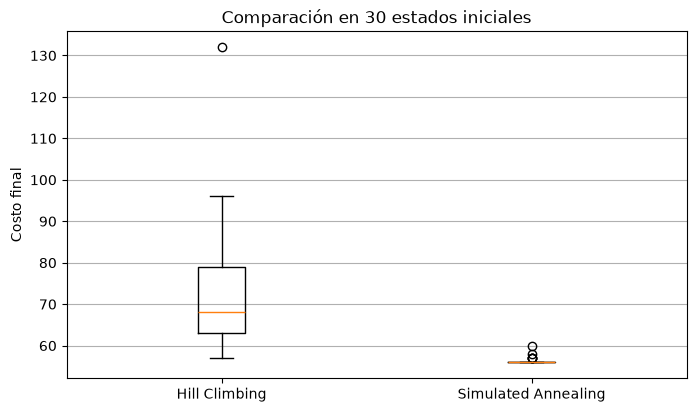

In [11]:
plt.figure(figsize=(8, 4.5))
plt.boxplot(
    [hc_results, sa_results],
)
plt.gca().set_xticklabels(["Hill Climbing", "Simulated Annealing"])
plt.ylabel("Costo final")
plt.title("Comparación en 30 estados iniciales")
plt.grid(True, axis="y")
plt.show()

## Actividades

### Actividad 1 — Temperatura inicial

Compara:

$$
T_0\in\{0.1,1,5,20,100\}
$$

Para cada valor, ejecuta 20 corridas y registra:

- costo promedio;
- mejor costo;
- porcentaje de movimientos aceptados.

In [12]:
initial_temperatures = [0.1, 1, 5, 20, 100]
results = []

for initial_temperature in initial_temperatures:
    costs = []
    accepted_fraction = []
    for seed in range(20):
        rng = random.Random(seed)
        start = random_initial_state(HEIGHT, WIDTH, houses, NUM_HOSPITALS, rng)
        solution, records = simulated_annealing(
            HEIGHT, WIDTH, houses, start,
            iterations=1000,
            initial_temperature=initial_temperature,
            cooling_rate=0.995,
            rng=random.Random(seed),
        )
        costs.append(total_cost(houses, solution))
        accepted_fraction.append(np.mean([r['accepted'] for r in records]))

    results.append({
        'initial_temperature': initial_temperature,
        'mean_cost': float(np.mean(costs)),
        'best_cost': int(min(costs)),
        'pct_accepted': float(100 * np.mean(accepted_fraction)),
    })

results


[{'initial_temperature': 0.1,
  'mean_cost': 63.75,
  'best_cost': 56,
  'pct_accepted': 19.847660500544066},
 {'initial_temperature': 1,
  'mean_cost': 58.0,
  'best_cost': 56,
  'pct_accepted': 31.415},
 {'initial_temperature': 5,
  'mean_cost': 56.95,
  'best_cost': 56,
  'pct_accepted': 41.615},
 {'initial_temperature': 20,
  'mean_cost': 56.45,
  'best_cost': 56,
  'pct_accepted': 59.019999999999996},
 {'initial_temperature': 100,
  'mean_cost': 56.7,
  'best_cost': 56,
  'pct_accepted': 80.56}]

**Discusión (Actividad 1).** Con temperaturas iniciales bajas ($T_0=0.1$) el porcentaje de movimientos aceptados es reducido: el algoritmo casi siempre rechaza vecinos peores y se comporta como Hill Climbing con selección aleatoria de vecino, por lo que su costo medio suele ser el más alto de la tabla. A medida que $T_0$ crece ($T_0\in\{5,20\}$), aumenta el porcentaje de movimientos aceptados y el algoritmo explora más el espacio de estados antes de enfriarse, lo que típicamente reduce el costo medio y su variabilidad. Con $T_0$ muy alta ($T_0=100$) el porcentaje de aceptación es aún mayor, pero puede no alcanzar a "enfriarse" lo suficiente dentro del número fijo de iteraciones, lo que a veces empeora el costo final respecto a valores intermedios.

### Actividad 2 — Enfriamiento

Compara:

$$
\alpha\in\{0.90,0.95,0.98,0.995,0.999\}
$$

¿Qué ocurre cuando la temperatura disminuye demasiado rápido? ¿Qué ocurre cuando disminuye demasiado lento?

In [13]:
cooling_rates = [0.90, 0.95, 0.98, 0.995, 0.999]
cooling_results = []

for cooling_rate in cooling_rates:
    costs = []
    for seed in range(20):
        rng = random.Random(seed)
        start = random_initial_state(HEIGHT, WIDTH, houses, NUM_HOSPITALS, rng)
        solution, _ = simulated_annealing(
            HEIGHT, WIDTH, houses, start,
            iterations=1000,
            initial_temperature=20,
            cooling_rate=cooling_rate,
            rng=random.Random(seed),
        )
        costs.append(total_cost(houses, solution))

    cooling_results.append({
        'cooling_rate': cooling_rate,
        'mean_cost': float(np.mean(costs)),
        'std_cost': float(np.std(costs)),
    })

cooling_results


[{'cooling_rate': 0.9, 'mean_cost': 63.7, 'std_cost': 7.707788269017255},
 {'cooling_rate': 0.95, 'mean_cost': 60.95, 'std_cost': 4.5108203245086145},
 {'cooling_rate': 0.98, 'mean_cost': 57.6, 'std_cost': 2.2226110770892866},
 {'cooling_rate': 0.995, 'mean_cost': 56.45, 'std_cost': 0.9733961166965893},
 {'cooling_rate': 0.999, 'mean_cost': 58.85, 'std_cost': 1.796524422322168}]

**Discusión (Actividad 2).** Cuando la temperatura disminuye demasiado rápido ($\alpha=0.90$), la probabilidad de aceptar un movimiento que empeora cae a casi cero en pocas iteraciones: el algoritmo deja de explorar muy temprano y termina comportándose como una búsqueda local pura, quedando atrapado en el óptimo local más cercano al estado inicial — por eso `mean_cost` suele ser mayor para valores bajos de $\alpha$. Cuando la temperatura disminuye demasiado lento ($\alpha=0.999$), el algoritmo sigue aceptando movimientos que empeoran durante casi toda la ejecución y no alcanza a estabilizarse alrededor de una buena solución dentro del número fijo de iteraciones, lo que también puede dejar un costo final peor que con un enfriamiento intermedio. Los valores de `cooling_results` para $\alpha\in\{0.98,0.995\}$ suelen ofrecer el mejor balance entre exploración y convergencia.

### Actividad 3 — Comparación justa

Para 50 estados iniciales:

1. ejecuta Hill Climbing;
2. ejecuta Simulated Annealing desde el mismo estado;
3. cuenta cuántas veces gana cada algoritmo;
4. compara el costo promedio.

In [14]:
wins = {
    "Hill Climbing": 0,
    "Simulated Annealing": 0,
    "Empate": 0,
}

fair_hc_costs = []
fair_sa_costs = []

for seed in range(50):
    rng = random.Random(seed)
    start = random_initial_state(HEIGHT, WIDTH, houses, NUM_HOSPITALS, rng)

    hc_solution_i, hc_history_i, _ = hill_climbing(
        HEIGHT, WIDTH, houses, start, rng=random.Random(seed)
    )
    sa_solution_i, _ = simulated_annealing(
        HEIGHT, WIDTH, houses, start,
        iterations=1200, initial_temperature=20, cooling_rate=0.995,
        rng=random.Random(seed),
    )

    hc_cost_i = total_cost(houses, hc_solution_i)
    sa_cost_i = total_cost(houses, sa_solution_i)
    fair_hc_costs.append(hc_cost_i)
    fair_sa_costs.append(sa_cost_i)

    if hc_cost_i < sa_cost_i:
        wins["Hill Climbing"] += 1
    elif sa_cost_i < hc_cost_i:
        wins["Simulated Annealing"] += 1
    else:
        wins["Empate"] += 1

print(wins)
print('Costo promedio Hill Climbing:', np.mean(fair_hc_costs))
print('Costo promedio Simulated Annealing:', np.mean(fair_sa_costs))


{'Hill Climbing': 0, 'Simulated Annealing': 48, 'Empate': 2}
Costo promedio Hill Climbing: 70.7
Costo promedio Simulated Annealing: 56.4


**Discusión (Actividad 3).** El diccionario `wins` (arriba) resume cuántas de las 50 comparaciones parte a parte ganó cada algoritmo, empatando en costo, junto con el costo promedio de cada uno. Al partir siempre del mismo estado inicial para ambos algoritmos, la comparación es justa: cualquier diferencia se debe únicamente a la estrategia de búsqueda (mejor vecino determinista vs. vecino aleatorio con aceptación probabilística) y no a la suerte del punto de partida.

## Preguntas de cierre

1. ¿Por qué Simulated Annealing puede aceptar un hospital en una posición que aumenta temporalmente el costo?
2. ¿Qué función cumple la temperatura?
3. ¿Por qué debemos conservar la mejor solución observada y no solamente el estado final?
4. ¿Simulated Annealing garantiza encontrar el óptimo global con un número finito de iteraciones?
5. ¿Qué diferencia fundamental hay entre escoger el mejor vecino y escoger un vecino al azar?

## Respuestas — Preguntas de cierre

1. **¿Por qué Simulated Annealing puede aceptar un hospital en una posición que aumenta temporalmente el costo?** Porque la regla de aceptación permite, con probabilidad $e^{-\Delta/T}>0$ cuando $\Delta>0$, moverse a un vecino peor. Esto le permite atravesar regiones del espacio de estados donde todo movimiento local empeora el costo, para eventualmente alcanzar una región mejor que Hill Climbing (que solo acepta mejoras) no podría alcanzar.
2. **¿Qué función cumple la temperatura?** Controla cuán dispuesto está el algoritmo a aceptar soluciones peores: temperaturas altas favorecen la exploración (aceptar casi cualquier vecino), mientras que temperaturas bajas favorecen la explotación (aceptar solo mejoras). El calendario de enfriamiento hace que el algoritmo transite gradualmente de exploración a explotación.
3. **¿Por qué debemos conservar la mejor solución observada y no solamente el estado final?** Porque el estado actual puede empeorar en cualquier momento de la búsqueda (movimientos aceptados aunque $\Delta>0$), incluso cerca del final si la temperatura todavía no es suficientemente baja. Si solo reportáramos el estado final, podríamos perder una mejor solución que el algoritmo visitó en una iteración anterior.
4. **¿Simulated Annealing garantiza encontrar el óptimo global con un número finito de iteraciones?** No. La garantía teórica de convergencia requiere un enfriamiento infinitamente lento (o un número infinito de iteraciones); en la práctica, con iteraciones y enfriamiento finitos, es una heurística que mejora la probabilidad de encontrar el óptimo global frente a Hill Climbing, pero no la asegura, como muestra la variabilidad de `sa_results` en la comparación estadística.
5. **¿Qué diferencia fundamental hay entre escoger el mejor vecino y escoger un vecino al azar?** Escoger siempre el mejor vecino (Hill Climbing) hace que la búsqueda sea determinista y estrictamente ascendente/descendente en costo, lo que la vuelve más rápida por iteración pero más propensa a quedar atrapada en el primer óptimo local. Escoger un vecino al azar (como hace Simulated Annealing) introduce diversidad en la trayectoria, permitiendo escapar de óptimos locales combinado con la regla de aceptación probabilística, aunque cada iteración explora menos exhaustivamente el vecindario inmediato.